In [6]:
import pandas as pd
# importa o arquivo e guarda em um dataframe do Pandas
df_dataset = pd.read_csv('/content/Cópia de notebooks.csv', sep=',', index_col=None)

# exibe o dataframe
df_dataset.head(3)

,marca,ano,qtd_nucleos,qtd_threads,ram,gpu_dedicada,ram_gpu,entradas_usb,duracao_bateria,resolucao_tela,tipo_tela,tela_touch,armazenamento_hdd,armazenamento_ssd,segmento,valor
0,razer,2022,10,10,16,não,0,2,412,FULLHD,AMOLED,não,0,2000,premium,15981
1,apple,2022,6,12,16,não,0,2,508,FULLHD,OLED,não,0,250,premium,16524
2,huawei,2022,8,12,8,não,0,2,496,4K,OLED,não,0,500,premium,21431


In [9]:
df_dataset_X = df_dataset.drop(['ano','segmento'],axis=1)

In [10]:
df_dataset_X.dtypes

marca                object
qtd_nucleos           int64
qtd_threads           int64
ram                   int64
gpu_dedicada         object
ram_gpu               int64
entradas_usb          int64
duracao_bateria       int64
resolucao_tela       object
tipo_tela            object
tela_touch           object
armazenamento_hdd     int64
armazenamento_ssd     int64
valor                 int64
dtype: object

In [11]:
!pip install scikit-survival

In [13]:
s = df_dataset_X.select_dtypes(include='object').columns
df_dataset_X[s] = df_dataset_X[s].astype("category")


In [14]:
from sksurv.preprocessing import OneHotEncoder

Xt = OneHotEncoder().fit_transform(df_dataset_X)
Xt.head()

,marca=apple,marca=asus,marca=dell,marca=hp,marca=huawei,marca=lenovo,marca=positivo,marca=razer,marca=samsung,marca=xiaomi,...,resolucao_tela=HD,resolucao_tela=QUADHD,tipo_tela=IPS,tipo_tela=OLED,tipo_tela=TN,tipo_tela=VA,tela_touch=sim,armazenamento_hdd,armazenamento_ssd,valor
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2000,15981
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,250,16524
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,500,21431
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,500,15844
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,250,12428


In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Suponha que você tenha seus dados X e os rótulos y
y = df_dataset['segmento']

# Divida os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(Xt, y, test_size=0.3, random_state=1)

# Crie um modelo KNN com um certo número de vizinhos (n_neighbors)
knn_model = KNeighborsClassifier(n_neighbors=1)

# Treine o modelo com os dados de treinamento
knn_model.fit(X_train, y_train)

# Faça previsões com o modelo nos dados de teste
y_pred = knn_model.predict(X_test)

# Calcule a acurácia das previsões
accuracy = accuracy_score(y_test, y_pred)
print("Acurácia:", accuracy)


Acurácia: 0.7603333333333333


Melhor valor de k: 1
Acurácia no conjunto de teste: 0.774


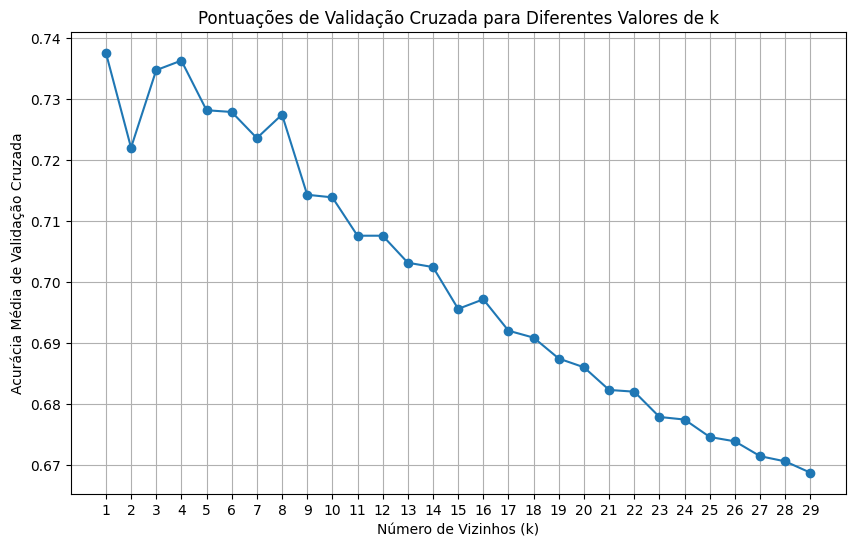

In [17]:
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

# Suponha que você tenha seus dados X e os rótulos y

# Divida os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(Xt, y, test_size=0.3, random_state=1234)

# Crie uma lista de valores de k para testar
k_values = list(range(1, 30))

# Inicialize uma lista para armazenar as pontuações de validação cruzada
cross_val_scores = []

# Teste diferentes valores de k usando validação cruzada
for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_model, X_train, y_train, cv=5)  # 5-fold cross-validation
    cross_val_scores.append(np.mean(scores))

# Encontre o valor de k com a melhor pontuação média de validação cruzada
best_k = k_values[np.argmax(cross_val_scores)]
print("Melhor valor de k:", best_k)

# Treine o modelo com o melhor valor de k usando todos os dados de treinamento
best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train, y_train)

# Avalie o modelo nos dados de teste
accuracy = best_knn_model.score(X_test, y_test)
print("Acurácia no conjunto de teste:", accuracy)


# Plote os resultados da validação cruzada em um gráfico
plt.figure(figsize=(10, 6))
plt.plot(k_values, cross_val_scores, marker='o')
plt.title('Pontuações de Validação Cruzada para Diferentes Valores de k')
plt.xlabel('Número de Vizinhos (k)')
plt.ylabel('Acurácia Média de Validação Cruzada')
plt.xticks(k_values)
plt.grid(True)
plt.show()

